# Aggression Classifier — Final Pipeline
**Arduino Nano 33 BLE Sense**

Two lightweight models trained on multi-source audio and quantized for Arduino deployment.

| | |
|---|---|
| **Architectures** | TinyCNN, TinyResidualNet |
| **Input** | 64-mel × 32-frame spectrogram, 1 second window, 0.5 second stride, no augmentation |
| **Training signal** | Focal loss · per-source loss weights · label smoothing · Mixup |
| **Early stopping** | Arduino-only val F1 |
| **Deployment** | int8 TFLite, Arduino Nano 33 BLE Sense |


## 0. Configuration

In [1]:
# Paths
ARDUINO_DIR   = "Arduino"   # Manually collected, split into neutral and aggressive folders of .wav files
RAVDESS_DIR   = "RAVDESS"   # Single folder containing keyed .wav files (https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio)
EMOTIONS_DIR  = "Emotions"  # Single folder all neutral .wav files (https://www.kaggle.com/datasets/tapakah68/emotions-on-audio-dataset)
SCREAMING_DIR = "Screaming" # Split into screaming and not screaming folders of .wav files (https://www.kaggle.com/datasets/whats2000/human-screaming-detection-dataset)

# Labels
NEUTRAL     = "neutral"
AGGRESSIVE  = "aggressive"
LABEL_TO_ID = {NEUTRAL: 0, AGGRESSIVE: 1}
ID_TO_LABEL = {0: NEUTRAL, 1: AGGRESSIVE}
ALL_SOURCES = ["ARDUINO", "EMOTIONS", "RAVDESS", "SCREAMING"]

# Audio — must match AggressionClassifier.ino
SAMPLE_RATE  = 16_000
TARGET_LEN   = 16_000       # 1-second window
CROP_HOP     = 8_000        # 50% overlap between consecutive crops
N_FFT        = 2048
HOP_LENGTH   = 512
N_MELS       = 64
MEL_FMIN     = 0.0
MEL_FMAX     = 8000.0
MEL_HTK      = True
MEL_NORM     = None
N_FRAMES     = 1 + TARGET_LEN // HOP_LENGTH   # 32
INPUT_SHAPE  = (N_MELS, N_FRAMES, 1)

# Split
SEED      = 42
VAL_FRAC  = 0.15
TEST_FRAC = 0.15

# Per-source loss weights (multiplied into focal loss per clip)
LOSS_WEIGHTS = {
    ("ARDUINO",   AGGRESSIVE): 8.0,
    ("ARDUINO",   NEUTRAL):    2.5,
    ("RAVDESS",   AGGRESSIVE): 3.0,
    ("RAVDESS",   NEUTRAL):    1.2,
    ("EMOTIONS",  NEUTRAL):    1.0,
    ("SCREAMING", AGGRESSIVE): 1.5,
    ("SCREAMING", NEUTRAL):    0.5,
}

# Mixup: blend Arduino-aggressive clips with other-source aggressive clips
MIXUP_BETA_PARAM   = 0.4
MIXUP_CLIPS_PER_FILE = 8

LABEL_SMOOTH_EPS = 0.10

# Training
BATCH_SIZE  = 64
EPOCHS      = 70
LR          = 1e-3
LR_PATIENCE = 8
ES_PATIENCE = 20

# Quantization
N_CALIB_SAMPLES = 256

# Output files
MODEL_HEADER_PATH = "model_data.h"
TFLITE_PATH       = "model_integer_quant.tflite"

print(f"Input shape  : {INPUT_SHAPE}  ({N_MELS * N_FRAMES} values)")
print(f"Crop hop     : {CROP_HOP} samples = {CROP_HOP / SAMPLE_RATE * 1000:.0f} ms  (50% overlap)")


Input shape  : (64, 32, 1)  (2048 values)
Crop hop     : 8000 samples = 500 ms  (50% overlap)


## 1. Imports

In [2]:
import os, glob, warnings, logging, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import librosa
from tqdm import tqdm
import tensorflow as tf
import tensorflow.lite as tflite
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.metrics import classification_report, confusion_matrix, f1_score as sk_f1, accuracy_score, recall_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Palette
C_NEU  = "#4C72B0"
C_AGG  = "#C44E52"
C_MF1  = "#2196F3"
C_REC  = "#FF5722"
C_GRID = "#E0E0E0"


## 2. Dataset Loading

In [3]:
def wav_files(directory, pattern="*.wav"):
    return sorted(glob.glob(os.path.join(directory, pattern)))

rows = []
for path in wav_files(os.path.join(ARDUINO_DIR, "Aggressive")):
    rows.append({"source": "ARDUINO", "path": path, "label": AGGRESSIVE})
for path in wav_files(os.path.join(ARDUINO_DIR, "Neutral")):
    rows.append({"source": "ARDUINO", "path": path, "label": NEUTRAL})

for path in wav_files(RAVDESS_DIR):
    parts = os.path.basename(path).replace(".wav", "").split("-")
    try:
        label = AGGRESSIVE if (parts[2] == "05" or (parts[2] == "06" and parts[3] == "02")) else NEUTRAL
    except IndexError:
        label = NEUTRAL
    rows.append({"source": "RAVDESS", "path": path, "label": label})

for path in wav_files(EMOTIONS_DIR):
    rows.append({"source": "EMOTIONS", "path": path, "label": NEUTRAL})

for path in wav_files(os.path.join(SCREAMING_DIR, "Screaming")):
    rows.append({"source": "SCREAMING", "path": path, "label": AGGRESSIVE})
for path in wav_files(os.path.join(SCREAMING_DIR, "NotScreaming")):
    rows.append({"source": "SCREAMING", "path": path, "label": NEUTRAL})

raw_df = pd.DataFrame(rows)
if raw_df.empty:
    raise ValueError("No audio files found — check paths in Section 0.")

counts = raw_df.groupby(["source", "label"]).size().unstack(fill_value=0)
print(f"Files loaded: {len(raw_df):,}\n")
print(counts.to_string())


Files loaded: 5,027

label      aggressive  neutral
source                        
ARDUINO            15       11
EMOTIONS            0       68
RAVDESS           288     1152
SCREAMING         862     2631


## 3. Train / Val / Test Split


In [4]:
path_metadata = raw_df.drop_duplicates("path").set_index("path")
path_groups = path_metadata["source"].astype(str) + "_" + path_metadata["label"].astype(str)
unique_paths = raw_df["path"].unique()
stratify_labels = path_groups.loc[unique_paths]

train_paths, remaining = train_test_split(
    unique_paths, test_size=VAL_FRAC + TEST_FRAC,
    random_state=SEED, stratify=stratify_labels)
val_paths, test_paths = train_test_split(
    remaining, test_size=0.5, random_state=SEED,
    stratify=stratify_labels.loc[remaining])

train_files = raw_df[raw_df["path"].isin(train_paths)].reset_index(drop=True)
val_files   = raw_df[raw_df["path"].isin(val_paths)  ].reset_index(drop=True)
test_files  = raw_df[raw_df["path"].isin(test_paths) ].reset_index(drop=True)

print("File-level split  70 / 15 / 15\n")
print(f"  {'Split':<6}  {'Files':>6}  {'neutral':>9}  {'aggressive':>11}  "
      + "  ".join(f"{s:>10}" for s in ALL_SOURCES))
for split_name, df in [("train", train_files), ("val", val_files), ("test", test_files)]:
    label_counts  = df["label"].value_counts()
    source_counts = df["source"].value_counts()
    print(f"  {split_name:<6}  {len(df):>6}  {label_counts.get(NEUTRAL, 0):>9}  "
          f"{label_counts.get(AGGRESSIVE, 0):>11}  "
          + "  ".join(f"{source_counts.get(s, 0):>10}" for s in ALL_SOURCES))


File-level split  70 / 15 / 15

  Split    Files    neutral   aggressive     ARDUINO    EMOTIONS     RAVDESS   SCREAMING
  train     3518       2703          815          18          48        1008        2444
  val        754        580          174           4          10         216         524
  test       755        579          176           4          10         216         525


## 4. Feature Extraction


In [5]:
def waveform_to_mel(waveform: np.ndarray) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=waveform, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=MEL_FMIN, fmax=MEL_FMAX,
        htk=MEL_HTK, norm=MEL_NORM)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    return mel_db[..., np.newaxis].astype(np.float32)

def files_to_arrays(files_df: pd.DataFrame, split_label: str = ""):
    spectrograms, labels, sources = [], [], []
    skipped = 0
    crop_log = {s: {"agg": 0, "neu": 0, "files": 0} for s in ALL_SOURCES}

    for _, row in tqdm(files_df.iterrows(), total=len(files_df), desc=split_label, leave=True):
        try:
            audio, _ = librosa.load(row["path"], sr=SAMPLE_RATE)
        except Exception as exc:
            print(f"  skip {row['path']}: {exc}")
            continue

        audio = audio.astype(np.float32)
        start, n_crops = 0, 0
        while start + TARGET_LEN <= len(audio):
            spectrograms.append(waveform_to_mel(audio[start:start + TARGET_LEN]))
            labels.append(LABEL_TO_ID[row["label"]])
            sources.append(row["source"])
            start += CROP_HOP
            n_crops += 1

        src = row["source"]
        if src in crop_log:
            crop_log[src]["files"] += 1
            if n_crops == 0:
                skipped += 1
            else:
                key = "agg" if row["label"] == AGGRESSIVE else "neu"
                crop_log[src][key] += n_crops

    print(f"  {'Source':<12}  {'Files':>6}  {'Agg crops':>10}  {'Neu crops':>10}")
    for src in ALL_SOURCES:
        lg = crop_log[src]
        if lg["files"] == 0:
            continue
        print(f"  {src:<12}  {lg['files']:>6}  {lg['agg']:>10}  {lg['neu']:>10}")

    X = np.stack(spectrograms)
    y = np.array(labels, dtype=np.int32)
    s = np.array(sources)
    print(f"  → {X.shape}  neutral={( y == 0).sum():,}  aggressive={(y == 1).sum():,}")
    return X, y, s


## 5. Build Feature Arrays

In [6]:
print("\n[1/3] Training")
X_train_raw, y_train_raw, src_train_raw = files_to_arrays(train_files, "train")

print("\n[2/3] Validation")
X_val, y_val, src_val = files_to_arrays(val_files, "val")

X_val_arduino = X_val[src_val == "ARDUINO"]
y_val_arduino = y_val[src_val == "ARDUINO"]

print("\n[3/3] Test")
X_test, y_test, src_test = files_to_arrays(test_files, "test")



[1/3] Training


train: 100%|███████████████████████████████████████████████████████████████████████| 3518/3518 [03:58<00:00, 14.74it/s]


  Source         Files   Agg crops   Neu crops
  ARDUINO           18         134         119
  EMOTIONS          48           0         701
  RAVDESS         1008        1245        4757
  SCREAMING       2444       11065       34528
  → (52549, 64, 32, 1)  neutral=40,105  aggressive=12,444

[2/3] Validation


val: 100%|███████████████████████████████████████████████████████████████████████████| 754/754 [00:49<00:00, 15.20it/s]


  Source         Files   Agg crops   Neu crops
  ARDUINO            4          33          28
  EMOTIONS          10           0         132
  RAVDESS          216         256        1013
  SCREAMING        524        2381        7421
  → (11264, 64, 32, 1)  neutral=8,594  aggressive=2,670

[3/3] Test


test: 100%|██████████████████████████████████████████████████████████████████████████| 755/755 [00:50<00:00, 14.95it/s]


  Source         Files   Agg crops   Neu crops
  ARDUINO            4          43          16
  EMOTIONS          10           0         124
  RAVDESS          216         261        1024
  SCREAMING        525        2390        7418
  → (11276, 64, 32, 1)  neutral=8,582  aggressive=2,694


## 6. Training Set — Focal Loss, Mixup, Sampler


In [7]:
def compute_loss_weights(y: np.ndarray, sources: np.ndarray) -> np.ndarray:
    weights = np.array([
        LOSS_WEIGHTS.get((sources[i], ID_TO_LABEL[int(y[i])]), 1.0)
        for i in range(len(y))
    ], dtype=np.float32)
    return weights / weights.mean()

def build_mixup_clips(X: np.ndarray, y: np.ndarray, sources: np.ndarray):
    arduino_agg_indices = np.where((sources == "ARDUINO") & (y == 1))[0]
    other_agg_indices   = np.where((sources != "ARDUINO") & (y == 1))[0]
    if len(arduino_agg_indices) == 0 or len(other_agg_indices) == 0:
        print("  Mixup skipped: need both Arduino and other-source aggressive clips")
        return (np.empty((0,) + INPUT_SHAPE, dtype=np.float32),
                np.empty(0, dtype=np.float32),
                np.empty(0, dtype=np.float32))

    rng = np.random.default_rng(SEED + 1)
    X_mix, y_mix, w_mix = [], [], []
    mixup_weight = LOSS_WEIGHTS.get(("ARDUINO", AGGRESSIVE), 8.0)

    for src_idx in arduino_agg_indices:
        for _ in range(MIXUP_CLIPS_PER_FILE):
            blend = float(rng.beta(MIXUP_BETA_PARAM, MIXUP_BETA_PARAM))
            other_idx = int(rng.choice(other_agg_indices))
            X_mix.append(blend * X[src_idx] + (1 - blend) * X[other_idx])
            y_mix.append(1.0 - LABEL_SMOOTH_EPS)
            w_mix.append(mixup_weight)

    return (np.stack(X_mix).astype(np.float32),
            np.array(y_mix, dtype=np.float32),
            np.array(w_mix, dtype=np.float32))

raw_weights   = compute_loss_weights(y_train_raw, src_train_raw)
soft_labels   = np.where(y_train_raw == 1,
                         1.0 - LABEL_SMOOTH_EPS,
                         LABEL_SMOOTH_EPS).astype(np.float32)

X_mix, y_mix, w_mix = build_mixup_clips(X_train_raw, y_train_raw, src_train_raw)

if len(X_mix) > 0:
    X_train    = np.concatenate([X_train_raw, X_mix])
    y_train    = np.concatenate([soft_labels,  y_mix])
    w_train    = np.concatenate([raw_weights,  w_mix])
    w_train   /= w_train.mean()
    src_train  = np.concatenate([src_train_raw, np.full(len(X_mix), "MIXUP")])
else:
    X_train, y_train, w_train, src_train = X_train_raw, soft_labels, raw_weights, src_train_raw

print(f"Training set: {X_train.shape}")
print(f"  original : {len(X_train_raw):,} clips")
print(f"  mixup    : {len(X_mix):,} clips ")

hard_labels      = (y_train >= 0.5).astype(int)
class_counts     = np.bincount(hard_labels)
sampler_weights  = np.where(hard_labels == 1,
                             1.0 / max(class_counts[1], 1),
                             1.0 / max(class_counts[0], 1)).astype(np.float64)
sampler_weights /= sampler_weights.sum()
print(f"  sampler  : {class_counts[0]:,} neutral / {class_counts[1]:,} aggressive")


Training set: (53621, 64, 32, 1)
  original : 52,549 clips
  mixup    : 1,072 clips 
  sampler  : 40,105 neutral / 13,516 aggressive


## 7. Model Architectures


In [8]:
def depthwise_sep_block(x, out_channels, stride=1):
    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(out_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def residual_block(x, out_channels):
    skip = x
    x = layers.DepthwiseConv2D(3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(out_channels, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if skip.shape[-1] != out_channels:
        skip = layers.Conv2D(out_channels, 1, use_bias=False)(skip)
        skip = layers.BatchNormalization()(skip)
    return layers.ReLU()(layers.Add()([x, skip]))

def make_tiny_residual_net():
    inp = Input(shape=INPUT_SHAPE, name="mel_input")
    x   = layers.Conv2D(12, 3, strides=2, padding="same", use_bias=False)(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.ReLU()(x)
    x   = depthwise_sep_block(x, 24, stride=2)
    x   = residual_block(x, 24)
    x   = depthwise_sep_block(x, 48, stride=2)
    x   = residual_block(x, 48)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(48, activation="relu")(x)
    x   = layers.Dropout(0.30)(x)
    out = layers.Dense(2, activation="softmax", name="output")(x)
    return models.Model(inp, out, name="TinyResidualNet")

def make_tiny_cnn():
    inp = Input(shape=INPUT_SHAPE, name="mel_input")
    x   = layers.Conv2D(12, 3, strides=2, padding="same", use_bias=False)(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.ReLU()(x)
    x   = depthwise_sep_block(x, 24, stride=2)
    x   = depthwise_sep_block(x, 48, stride=2)
    x   = depthwise_sep_block(x, 64, stride=1)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(48, activation="relu")(x)
    x   = layers.Dropout(0.30)(x)
    out = layers.Dense(2, activation="softmax", name="output")(x)
    return models.Model(inp, out, name="TinyCNN")

PEAK_ACTIVATIONS = {"TinyResidualNet": 32 * 16 * 12, "TinyCNN": 32 * 16 * 12}

def estimate_arena_bytes(model_name, overhead_kb=16):
    peak = PEAK_ACTIVATIONS.get(model_name, 32 * 16 * 12)
    raw  = 2 * peak + overhead_kb * 1024
    return ((raw + 4095) // 4096) * 4096

SAFE_OPS = {"CONV_2D", "DEPTHWISE_CONV_2D", "ADD", "MEAN",
            "FULLY_CONNECTED", "SOFTMAX", "RELU", "RELU6",
            "MUL", "DEQUANTIZE", "QUANTIZE"}

def check_ops(tflite_bytes, name):
    interp = tflite.Interpreter(model_content=tflite_bytes)
    try:
        ops = {o["op_name"] for o in interp._get_ops_details()}
    except Exception:
        ops = set()
    unsafe = ops - SAFE_OPS
    status = "OK" if not unsafe else f"UNSAFE: {sorted(unsafe)}"
    print(f"  {name}: {status}")
    return unsafe

print(f"{'Model':<22} {'Params':>8}  {'Arena':>8}")
print("-" * 42)
for build_fn in [make_tiny_residual_net, make_tiny_cnn]:
    m     = build_fn()
    arena = estimate_arena_bytes(m.name)
    print(f"{m.name:<22} {m.count_params():>8,}  {arena // 1024:>6} KB")


Model                    Params     Arena
------------------------------------------
TinyResidualNet           8,906      28 KB
TinyCNN                   9,522      28 KB


## 8. Loss, Callbacks, and Training


In [9]:
def focal_loss(gamma=2.5):
    def loss_fn(y_true, y_pred):
        y_true    = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        soft_true = tf.stack([1.0 - y_true, y_true], axis=1)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_ent = -tf.reduce_sum(soft_true * tf.math.log(y_pred), axis=-1)
        confidence = tf.reduce_sum(soft_true * y_pred, axis=-1)
        return tf.reduce_mean((1 - confidence) ** gamma * cross_ent)
    loss_fn.__name__ = "focal_loss"
    return loss_fn

class ValidationMetricsCallback(Callback):
    def __init__(self, X_val_all, y_val_all, X_val_ard, y_val_ard):
        super().__init__()
        self.X_val_all = X_val_all
        self.y_val_all = y_val_all
        self.X_val_ard = X_val_ard
        self.y_val_ard = y_val_ard

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        preds_all = np.argmax(self.model.predict(self.X_val_all, verbose=0), axis=1)
        logs["val_acc"]  = accuracy_score(self.y_val_all, preds_all)
        logs["val_mf1"]  = sk_f1(self.y_val_all, preds_all, average="macro",    zero_division=0)
        logs["val_wf1"]  = sk_f1(self.y_val_all, preds_all, average="weighted", zero_division=0)

        if len(self.X_val_ard) > 0:
            preds_ard        = np.argmax(self.model.predict(self.X_val_ard, verbose=0), axis=1)
            logs["val_ard_acc"]  = accuracy_score(self.y_val_ard, preds_ard)
            logs["val_ard_mf1"] = sk_f1(self.y_val_ard, preds_ard, average="macro", zero_division=0)
            logs["val_ard_wf1"] = sk_f1(self.y_val_ard, preds_ard, average="weighted", zero_division=0)
        else:
            logs["val_ard_acc"]  = logs["val_acc"]
            logs["val_ard_mf1"] = logs["val_mf1"]
            logs["val_ard_wf1"] = logs["val_wf1"]

        print(f"  epoch {epoch+1:3d}  val_acc {logs['val_acc']:.4f}  val_mf1 {logs['val_mf1']:.4f}  val_wf1 {logs['val_wf1']:.4f}  "
              f"val_ard_acc {logs['val_ard_acc']:.4f}  val_ard_mf1 {logs['val_ard_mf1']:.4f}  val_ard_wf1 {logs['val_ard_wf1']:.4f}")


def train_model(build_fn, model_name):
    model = build_fn()
    model.compile(optimizer=Adam(LR), loss=focal_loss(gamma=2.5), metrics=["accuracy"])

    metrics_cb = ValidationMetricsCallback(X_val, y_val, X_val_arduino, y_val_arduino)
    early_stop = EarlyStopping(monitor="val_ard_mf1", mode="max", patience=ES_PATIENCE, restore_best_weights=True, verbose=0)
    lr_sched   = ReduceLROnPlateau(monitor="val_ard_mf1", mode="max", patience=LR_PATIENCE, factor=0.5, min_lr=1e-5, verbose=0)

    draw_indices    = np.random.default_rng(SEED).choice(
        len(X_train), size=len(X_train), replace=True, p=sampler_weights)
    X_drawn = X_train[draw_indices]
    y_drawn = y_train[draw_indices]
    w_drawn = w_train[draw_indices]

    history = model.fit(
        X_drawn, y_drawn, sample_weight=w_drawn,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[metrics_cb, early_stop, lr_sched],
        verbose=0, shuffle=True)

    n_epochs = len(history.history["loss"])
    best_ep  = int(np.argmax(history.history["val_ard_mf1"]))
    h        = history.history
    print(f"\n  Stopped at epoch {n_epochs}  |  best epoch {best_ep + 1}")
    print(f"  val_acc={h['val_acc'][best_ep]:.4f}  "
          f"val_mf1={h['val_mf1'][best_ep]:.4f}  "
          f"val_wf1={h['val_wf1'][best_ep]:.4f}  "
          f"val_ard_acc={h['val_ard_acc'][best_ep]:.4f}  "
          f"val_ard_mf1={h['val_ard_mf1'][best_ep]:.4f}  "
          f"val_ard_wf1={h['val_ard_wf1'][best_ep]:.4f}  ")
    return model, history.history, n_epochs


## 9. Train Both Models

In [10]:
all_results = {}

for model_name, build_fn in [("TinyResidualNet", make_tiny_residual_net), ("TinyCNN", make_tiny_cnn)]:
    print()
    print(f"{'='*56}")
    print(f"  {model_name}")
    print(f"{'='*56}")
    model, history, n_epochs = train_model(build_fn, model_name)

    test_probs = model.predict(X_test, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)

    acc = accuracy_score(y_test, test_preds)
    mf1 = sk_f1(y_test, test_preds, average="macro",    zero_division=0)
    wf1 = sk_f1(y_test, test_preds, average="weighted", zero_division=0)

    arduino_mask = src_test == "ARDUINO"
    ard_acc = accuracy_score(y_test[arduino_mask], test_preds[arduino_mask])
    ard_mf1 = sk_f1(y_test[arduino_mask], test_preds[arduino_mask], average="macro", zero_division=0)
    ard_wf1 = sk_f1(y_test[arduino_mask], test_preds[arduino_mask], average="weighted", zero_division=0)
    ard_rec  = recall_score(y_test[arduino_mask], test_preds[arduino_mask], pos_label=1, zero_division=0)
    ard_nrec = recall_score(y_test[arduino_mask], test_preds[arduino_mask], pos_label=0, zero_division=0)

    best_val_ard_mf1 = float(max(history["val_ard_mf1"]))

    all_results[model_name] = dict(
        model=model, history=history, n_epochs=n_epochs,
        test_probs=test_probs, test_preds=test_preds,
        acc=acc, mf1=mf1, wf1=wf1,
        ard_acc=ard_acc, ard_mf1=ard_mf1, ard_wf1=ard_wf1,
        best_val_ard_mf1=best_val_ard_mf1,
        params=model.count_params(),
    )
    print(f"  Test overall : acc={acc:.4f}  mf1={mf1:.4f}  wf1={wf1:.4f}")
    print(f"  Test Arduino : acc={ard_acc:.4f}  mf1={ard_mf1:.4f}  wf1={ard_wf1:.4f}")

best_name = max(all_results, key=lambda k: all_results[k]["best_val_ard_mf1"])
print(f"\nBest model: {best_name}")



  TinyResidualNet
  epoch   1  val_acc 0.7455  val_mf1 0.6872  val_wf1 0.7582  val_ard_acc 0.5738  val_ard_mf1 0.5594  val_ard_wf1 0.5529
  epoch   2  val_acc 0.7082  val_mf1 0.6654  val_wf1 0.7283  val_ard_acc 0.3770  val_ard_mf1 0.3561  val_ard_wf1 0.3656
  epoch   3  val_acc 0.7275  val_mf1 0.6796  val_wf1 0.7448  val_ard_acc 0.3934  val_ard_mf1 0.3828  val_ard_wf1 0.3895
  epoch   4  val_acc 0.7357  val_mf1 0.6857  val_wf1 0.7516  val_ard_acc 0.3443  val_ard_mf1 0.3427  val_ard_wf1 0.3400
  epoch   5  val_acc 0.7798  val_mf1 0.7120  val_wf1 0.7855  val_ard_acc 0.4098  val_ard_mf1 0.3900  val_ard_wf1 0.3810
  epoch   6  val_acc 0.7834  val_mf1 0.7083  val_wf1 0.7861  val_ard_acc 0.4590  val_ard_mf1 0.4372  val_ard_wf1 0.4282
  epoch   7  val_acc 0.7822  val_mf1 0.7114  val_wf1 0.7866  val_ard_acc 0.4098  val_ard_mf1 0.3900  val_ard_wf1 0.3810
  epoch   8  val_acc 0.7587  val_mf1 0.6987  val_wf1 0.7694  val_ard_acc 0.4754  val_ard_mf1 0.4637  val_ard_wf1 0.4573
  epoch   9  val_acc 

## 10. Results

In [11]:
print(f"  {'Model':<22} {'Params':>7}  {'Acc':>6}  {'mF1':>6}  {'wF1':>6}  "
      f"{'Ard mF1':>8}  {'Ard Agg':>8}  {'Ard Neu':>8}  {'Epochs':>7}")
print("  " + "-" * 80)
for name, r in sorted(all_results.items(), key=lambda kv: -kv[1]["ard_mf1"]):
    print(f"  {name:<22} {r['params']:>7,}  {r['acc']:>6.3f}  {r['mf1']:>6.3f}  {r['wf1']:>6.3f}  "
          f"{r['ard_mf1']:>8.3f}  {r['ard_wf1']:>8.3f}  {r['n_epochs']:>7}")

print(f"\n  {'Model':<22}  {'Source':<12}  {'mF1':>6}  {'AggRec':>7}  {'NeuRec':>7}  {'n':>5}")
print("  " + "-" * 70)
for name, r in sorted(all_results.items(), key=lambda kv: -kv[1]["ard_mf1"]):
    for src in ALL_SOURCES:
        mask = src_test == src
        if mask.sum() == 0:
            continue
        yt, yp = y_test[mask], r["test_preds"][mask]
        n_agg, n_neu = int((yt == 1).sum()), int((yt == 0).sum())
        mf1_src = sk_f1(yt, yp, average="macro", zero_division=0)
        rec_agg = recall_score(yt, yp, pos_label=1, zero_division=0) if n_agg else float("nan")
        rec_neu = recall_score(yt, yp, pos_label=0, zero_division=0) if n_neu else float("nan")
        arrow   = ">>>" if src == "ARDUINO" else "   "
        print(f"{arrow} {name:<22}  {src:<12}  {mf1_src:>6.3f}  "
              f"{rec_agg:>7.3f}  {rec_neu:>7.3f}  {mask.sum():>5}")
    print("  " + "-" * 70)


  Model                   Params     Acc     mF1     wF1   Ard mF1   Ard Agg   Ard Neu   Epochs
  --------------------------------------------------------------------------------
  TinyCNN                  9,522   0.644   0.621   0.670     0.624     0.639       21
  TinyResidualNet          8,906   0.758   0.701   0.769     0.454     0.433       21

  Model                   Source           mF1   AggRec   NeuRec      n
  ----------------------------------------------------------------------
>>> TinyCNN                 ARDUINO        0.624    0.488    1.000     59
    TinyCNN                 EMOTIONS       0.479      nan    0.919    124
    TinyCNN                 RAVDESS        0.563    0.701    0.585   1285
    TinyCNN                 SCREAMING      0.626    0.857    0.577   9808
  ----------------------------------------------------------------------
>>> TinyResidualNet         ARDUINO        0.454    0.256    1.000     59
    TinyResidualNet         EMOTIONS       0.492      nan   

## 11. Training Curves

In [20]:
# model_names = list(all_results.keys())
# fig, axes   = plt.subplots(2, len(model_names), figsize=(7 * len(model_names), 9))
# fig.suptitle("Training Curves", fontsize=14, fontweight="bold", y=1.01)

# for col, name in enumerate(model_names):
#     h       = all_results[name]["history"]
#     epochs  = range(1, all_results[name]["n_epochs"] + 1)
#     best_ep = int(np.argmax(h["val_ard_mf1"])) + 1

#     ax = axes[0, col]
#     ax.plot(epochs, h["loss"],     color="#555", lw=1.5, label="train loss")
#     ax.plot(epochs, h["val_loss"], color="#555", lw=1.5, linestyle="--", label="val loss")
#     ax.axvline(best_ep, color="#E53935", lw=1.2, linestyle=":", alpha=0.8, label=f"best ep {best_ep}")
#     ax.set_title(name, fontsize=12, fontweight="bold")
#     ax.set_ylabel("Focal Loss")
#     ax.legend(fontsize=8)
#     ax.set_facecolor("#FAFAFA")
#     ax.grid(color=C_GRID, linewidth=0.8)
#     for spine in ax.spines.values():
#         spine.set_visible(False)

#     ax = axes[1, col]
#     ax.plot(epochs, h["val_acc"],     color="#43A047", lw=2,   label="val acc")
#     ax.plot(epochs, h["val_mf1"],     color=C_MF1,    lw=2,   label="val mF1")
#     ax.plot(epochs, h["val_wf1"],     color="#7B1FA2", lw=2,   label="val wF1")
#     ax.plot(epochs, h["val_ard_mf1"], color=C_AGG,    lw=2,   linestyle="-.", label="val ard mF1")
#     ax.axvline(best_ep, color="#E53935", lw=1.2, linestyle=":", alpha=0.8)
#     ax.set_ylim(0, 1.05)
#     ax.set_ylabel("Score")
#     ax.set_xlabel("Epoch")
#     ax.legend(fontsize=8)
#     ax.set_facecolor("#FAFAFA")
#     ax.grid(color=C_GRID, linewidth=0.8)
#     for spine in ax.spines.values():
#         spine.set_visible(False)
#     ax.text(best_ep, 0.03, f"ep {best_ep}", fontsize=7, color="#E53935", ha="center")

# plt.tight_layout()
# plt.savefig("training_curves.png", dpi=130, bbox_inches="tight")
# plt.show()


## 12. Evaluation — Confusion Matrices & Score Distributions

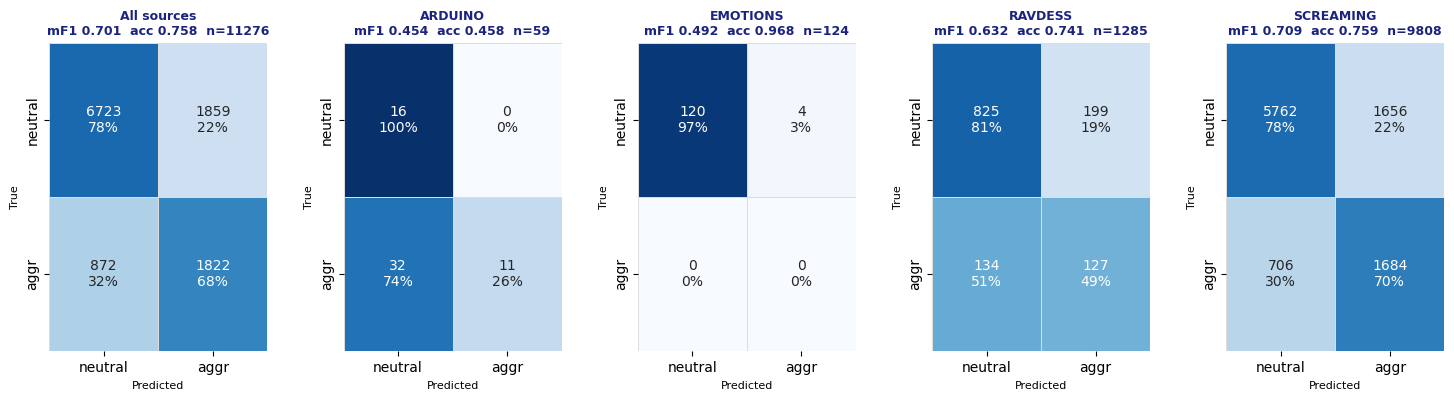


TinyResidualNet — classification report (all test clips)
              precision    recall  f1-score   support

     neutral      0.885     0.783     0.831      8582
  aggressive      0.495     0.676     0.572      2694

    accuracy                          0.758     11276
   macro avg      0.690     0.730     0.701     11276
weighted avg      0.792     0.758     0.769     11276



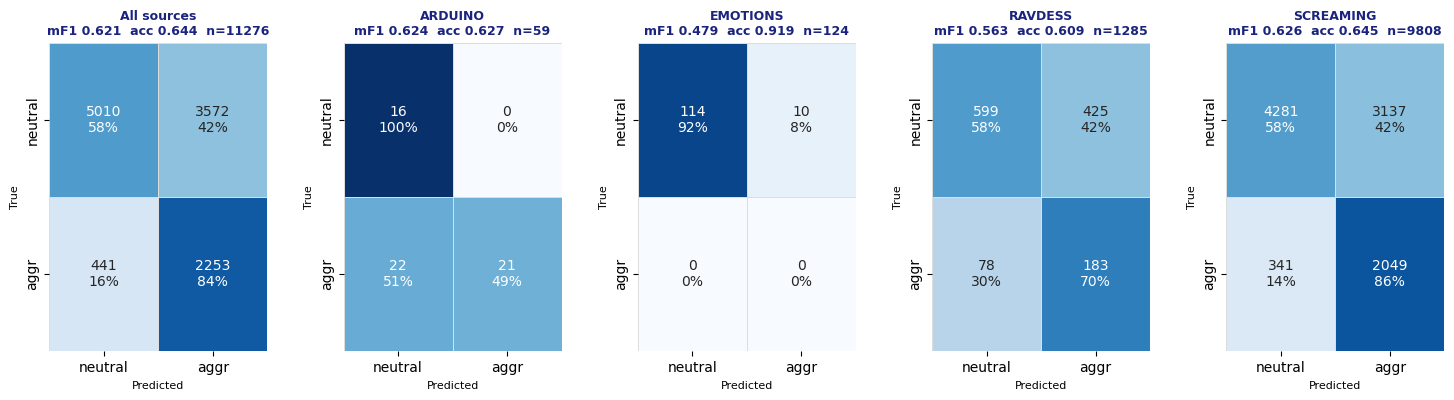


TinyCNN — classification report (all test clips)
              precision    recall  f1-score   support

     neutral      0.919     0.584     0.714      8582
  aggressive      0.387     0.836     0.529      2694

    accuracy                          0.644     11276
   macro avg      0.653     0.710     0.621     11276
weighted avg      0.792     0.644     0.670     11276



In [13]:
def draw_confusion_matrix(ax, y_true, y_pred, title, highlight=False):
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    annot  = np.array([[f"{cm[i,j]}\n{cm_pct[i,j]:.0%}" for j in range(2)]
                        for i in range(2)])
    cmap   = "Reds" if highlight else "Blues"
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap=cmap, ax=ax,
                xticklabels=["neutral", "aggr"],
                yticklabels=["neutral", "aggr"],
                cbar=False, vmin=0, vmax=1, linewidths=0.5, linecolor="#DDD")
    mf1 = sk_f1(y_true, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    color = "#B71C1C" if highlight else "#1A237E"
    ax.set_title(f"{title}\nmF1 {mf1:.3f}  acc {acc:.3f}  n={len(y_true)}",
                 fontsize=9, fontweight="bold", color=color)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)


for name, r in all_results.items():
    fig = plt.figure(figsize=(18, 4))
    gs   = fig.add_gridspec(1, 5, hspace=0.35, wspace=0.35)
    axes = [fig.add_subplot(gs[0, col]) for col in range(5)]

    draw_confusion_matrix(axes[0], y_test, r["test_preds"], "All sources")

    for i, src in enumerate(ALL_SOURCES):
        mask = src_test == src
        if mask.sum() == 0:
            axes[i + 1].axis("off")
            continue

        draw_confusion_matrix(
            axes[i + 1],
            y_test[mask],
            r["test_preds"][mask],
            src
        )

    plt.savefig(f"eval_{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

    print(f"\n{name} — classification report (all test clips)")
    print(classification_report(
        y_test,
        r["test_preds"],
        target_names=["neutral", "aggressive"],
        digits=3
    ))


## 13. int8 Quantization

In [14]:
rng_calib  = np.random.default_rng(SEED + 999)
agg_pool   = np.where(y_train_raw == 1)[0]
neu_pool   = np.where(y_train_raw == 0)[0]
n_agg_cal  = max(int(N_CALIB_SAMPLES * 0.40), min(len(agg_pool), N_CALIB_SAMPLES // 2))
calib_idx  = np.concatenate([
    rng_calib.choice(agg_pool, size=min(n_agg_cal, len(agg_pool)), replace=False),
    rng_calib.choice(neu_pool, size=min(N_CALIB_SAMPLES - n_agg_cal, len(neu_pool)), replace=False),
])
rng_calib.shuffle(calib_idx)
X_calib = X_train_raw[calib_idx]
print(f"Calibration set: {X_calib.shape}  "
      f"agg={(y_train_raw[calib_idx] == 1).sum()}  "
      f"neu={(y_train_raw[calib_idx] == 0).sum()}")


def representative_data():
    for i in range(len(X_calib)):
        yield [X_calib[i:i+1]]

def quantize_model(keras_model):
    converter = tflite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations             = [tflite.Optimize.DEFAULT]
    converter.representative_dataset    = representative_data
    converter.target_spec.supported_ops = [tflite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type      = tf.int8
    converter.inference_output_type     = tf.int8

    with open(os.devnull, "w") as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = devnull, devnull
        try:
            model_bytes = converter.convert()
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

    interp = tflite.Interpreter(model_content=model_bytes)
    interp.allocate_tensors()
    return model_bytes, interp

def run_int8_inference(interp, X, y):
    inp_detail = interp.get_input_details()[0]
    out_detail = interp.get_output_details()[0]
    inp_scale, inp_zero = inp_detail["quantization"]
    out_scale, out_zero = out_detail["quantization"]
    preds, probs = [], []
    for i in range(len(X)):
        x_quant = np.round(X[i:i+1] / inp_scale + inp_zero).clip(-128, 127).astype(np.int8)
        interp.set_tensor(inp_detail["index"], x_quant)
        interp.invoke()
        out_quant = interp.get_tensor(out_detail["index"])
        out_float = (out_quant.astype(np.float32) - out_zero) * out_scale
        probs.append(out_float[0])
        preds.append(int(np.argmax(out_float)))
    return np.array(preds), np.array(probs)

quantized = {}
for name, r in all_results.items():
    print(f"\nQuantizing {name}...")
    model_bytes, interp = quantize_model(r["model"])
    inp_d = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]

    preds_int8, probs_int8 = run_int8_inference(interp, X_test, y_test)

    mf1_int8 = sk_f1(y_test, preds_int8, average="macro",    zero_division=0)
    wf1_int8 = sk_f1(y_test, preds_int8, average="weighted", zero_division=0)
    degradation = wf1_int8 - r["wf1"]

    ard_mask  = src_test == "ARDUINO"
    ard_mf1   = sk_f1(y_test[ard_mask], preds_int8[ard_mask], average="macro", zero_division=0)
    ard_wf1   = sk_f1(y_test[ard_mask], preds_int8[ard_mask], average="weighted", zero_division=0)
    arena     = estimate_arena_bytes(r["model"].name)
    size_kb   = len(model_bytes) / 1024

    quantized[name] = dict(
        model_bytes=model_bytes, interp=interp,
        preds=preds_int8, probs=probs_int8,
        mf1=mf1_int8, wf1=wf1_int8,
        ard_mf1=ard_mf1, ard_wf1=ard_wf1, best_val_ard_mf1=all_results[name]["best_val_ard_mf1"],
        degradation=degradation, size_kb=size_kb, arena=arena,
        inp_scale=inp_d["quantization"][0], inp_zero=inp_d["quantization"][1],
        out_scale=out_d["quantization"][0], out_zero=out_d["quantization"][1],
        inp_shape=list(inp_d["shape"]),
    )
    deg_flag   = "OK"   if abs(degradation) < 0.03 else "WARN"
    arena_flag = "OK"   if arena <= 81920          else "FAIL"
    check_ops(model_bytes, name)
    print(f"  {size_kb:.1f} KB  arena {arena // 1024} KB [{arena_flag}]  "
          f"wF1 delta {degradation:+.4f} [{deg_flag}]")
    print(f"  mf1={mf1_int8:.4f}  wf1={wf1:.4f}  "
          f"ard_mf1={ard_mf1:.4f}  ard_wf1={ard_wf1:.4f}")

best_int8 = max(quantized, key=lambda k: quantized[k]["best_val_ard_mf1"])

print(f"\n  {'Model':<22} {'KB':>5}  {'mF1':>6}  {'wF1':>8}  {'Arduino mF1':>8}  {'Arduino mF1':>8}  {'Arena':>7}")
print("  " + "-" * 70)
for name in sorted(quantized, key=lambda k: -quantized[k]["ard_mf1"]):
    q = quantized[name]
    print(f"  {name:<22} {q['size_kb']:>5.1f}  {q['mf1']:>6.4f}  {q['wf1']:>8.4f}   "
          f"{q['ard_mf1']:>8.4f}  {q['ard_wf1']:>8.4f}  {q['arena'] // 1024:>5} KB")
print(f"\nBest int8: {best_int8}")


Calibration set: (256, 64, 32, 1)  agg=128  neu=128

Quantizing TinyResidualNet...
  TinyResidualNet: OK
  27.6 KB  arena 28 KB [OK]  wF1 delta +0.0051 [OK]
  mf1=0.7050  wf1=0.6698  ard_mf1=0.4722  ard_wf1=0.4558

Quantizing TinyCNN...
  TinyCNN: OK
  24.4 KB  arena 28 KB [OK]  wF1 delta +0.0022 [OK]
  mf1=0.6233  wf1=0.6698  ard_mf1=0.6244  ard_wf1=0.6390

  Model                     KB     mF1       wF1  Arduino mF1  Arduino mF1    Arena
  ----------------------------------------------------------------------
  TinyCNN                 24.4  0.6233    0.6720     0.6244    0.6390     28 KB
  TinyResidualNet         27.6  0.7050    0.7742     0.4722    0.4558     28 KB

Best int8: TinyResidualNet


## 14. Threshold Sweep


In [21]:
def run_threshold_sweep(model_name, precision_floor=0.30):
    q      = quantized[model_name]
    interp = q["interp"]
    inp_d  = interp.get_input_details()[0]
    out_d  = interp.get_output_details()[0]

    val_probs = []
    for i in range(len(X_val)):
        x_q = np.round(X_val[i:i+1] / q["inp_scale"] + q["inp_zero"]).clip(-128, 127).astype(np.int8)
        interp.set_tensor(inp_d["index"], x_q)
        interp.invoke()
        o_q = interp.get_tensor(out_d["index"])
        o_f = (o_q.astype(np.float32) - q["out_zero"]) * q["out_scale"]
        val_probs.append(float(o_f[0, 1]))
    val_probs = np.array(val_probs)

    ard_val_mask   = src_val == "ARDUINO"
    ard_val_probs  = val_probs[ard_val_mask]
    ard_val_labels = y_val[ard_val_mask]

    rows = []
    for thr in np.linspace(0.05, 0.90, 86):
        pv   = (val_probs >= thr).astype(int)
        tp   = ((pv == 1) & (y_val == 1)).sum()
        fp   = ((pv == 1) & (y_val == 0)).sum()
        fn   = ((pv == 0) & (y_val == 1)).sum()
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        if len(ard_val_probs) > 0:
            pv_ard  = (ard_val_probs >= thr).astype(int)
            ard_mf1 = sk_f1(ard_val_labels, pv_ard, average="macro", zero_division=0)
        else:
            ard_mf1 = f1
        rows.append(dict(thr=thr, prec=prec, rec=rec, f1=f1, ard_mf1=ard_mf1))

    sweep_df  = pd.DataFrame(rows)
    eligible  = sweep_df[sweep_df["prec"] >= precision_floor]
    best_row  = (eligible if not eligible.empty else sweep_df).loc[
        (eligible if not eligible.empty else sweep_df)["ard_mf1"].idxmax()]
    return round(float(best_row["thr"]), 2), sweep_df, best_row

PRECISION_FLOOR  = 0.30
optimal_thresholds = {}
sweep_order = [best_int8] + [k for k in quantized if k != best_int8]

# fig, axes = plt.subplots(len(sweep_order), 1, figsize=(7, 5 * len(sweep_order)), squeeze=False)
# if len(sweep_order) == 1:
#     axes = axes[np.newaxis, :]
# fig.suptitle("Threshold Sweep", fontsize=12, fontweight="bold")

for row_idx, name in enumerate(sweep_order):
    opt_thr, sweep_df, best_row = run_threshold_sweep(name, PRECISION_FLOOR)
    optimal_thresholds[name]    = opt_thr

    print(f"{name}: thr={opt_thr:.2f}  "
          f"prec={best_row['prec']:.3f}  rec={best_row['rec']:.3f}  "
          f"ard_mf1={best_row['ard_mf1']:.3f}")

#     ax = axes[row_idx, 0]
#     ax.fill_between(sweep_df["thr"], sweep_df["prec"], alpha=0.15, color="#4CAF50")
#     ax.fill_between(sweep_df["thr"], sweep_df["rec"],  alpha=0.15, color=C_REC)
#     ax.plot(sweep_df["thr"], sweep_df["prec"], color="#4CAF50", lw=2, label="Precision")
#     ax.plot(sweep_df["thr"], sweep_df["rec"],  color=C_REC,     lw=2, label="Recall")
#     ax.plot(sweep_df["thr"], sweep_df["f1"],   color=C_MF1,     lw=2, linestyle="--", label="F1")
#     ax.axvline(opt_thr, color="#E53935", lw=1.5, linestyle=":")
#     ax.axhline(PRECISION_FLOOR, color="#999", lw=1, linestyle=":")
#     ax.set_title(f"{name} — Overall", fontsize=9, fontweight="bold")
#     ax.set_xlabel("Threshold"); ax.set_ylim(0, 1.05)
#     ax.legend(fontsize=8)
#     ax.set_facecolor("#FAFAFA"); ax.grid(color=C_GRID)
#     for sp in ax.spines.values(): sp.set_visible(False)

# plt.tight_layout()
# plt.savefig("threshold_sweep.png", dpi=130, bbox_inches="tight")
# plt.show()

print("\nDeployment thresholds:")
for n, t in optimal_thresholds.items():
    print(f"  {n}: {t:.2f}")


TinyResidualNet: thr=0.49  prec=0.447  rec=0.700  ard_mf1=0.555
TinyCNN: thr=0.49  prec=0.367  rec=0.842  ard_mf1=0.483

Deployment thresholds:
  TinyResidualNet: 0.49
  TinyCNN: 0.49


## 15. Model & Threshold Override *(optional)*

In [16]:
# OVERRIDE_MODEL = TinyCNN # "TinyResidualNet" or "TinyCNN"
# OVERRIDE_THR   = 0.45

if "OVERRIDE_MODEL" in dir() and OVERRIDE_MODEL in quantized:
    best_int8 = OVERRIDE_MODEL
    print(f"[override] model     → {best_int8}")
else:
    print(f"[auto]     model     = {best_int8}")

if "OVERRIDE_THR" in dir():
    optimal_thresholds[best_int8] = float(OVERRIDE_THR)
    print(f"[override] threshold → {OVERRIDE_THR:.2f}")
else:
    print(f"[auto]     threshold = {optimal_thresholds.get(best_int8, '(run sweep first)')}")

sweep_order = [best_int8] + [k for k in quantized if k != best_int8]
print(f"\nEvaluation order: {sweep_order}")


[auto]     model     = TinyResidualNet
[auto]     threshold = 0.49

Evaluation order: ['TinyResidualNet', 'TinyCNN']


## 16. Arduino File Evaluation


Arduino files: 26  agg=15  neu=11

  True          Crops    MeanP    MaxP  Pred          Split   OK?    File
  ------------------------------------------------------------------------
  aggressive       14    0.493   0.613  aggressive    train   ✓      recording-1.wav
  aggressive       10    0.517   0.680  aggressive    train   ✓      recording-10.wav
  aggressive       10    0.480   0.641  neutral       train   ✗      recording-11.wav
  aggressive       10    0.507   0.641  aggressive    test    ✓      recording-12.wav
  aggressive       10    0.541   0.727  aggressive    train   ✓      recording-13.wav
  aggressive       10    0.419   0.473  neutral       train   ✗      recording-14.wav
  aggressive       14    0.520   0.625  aggressive    test    ✓      recording-2.wav
  aggressive       14    0.497   0.582  aggressive    val     ✓      recording-3.wav
  aggressive       14    0.554   0.770  aggressive    train   ✓      recording-4.wav
  aggressive       14    0.585   0.812  aggres

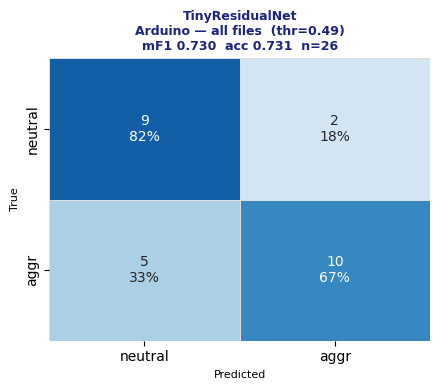


  True          Crops    MeanP    MaxP  Pred          Split   OK?    File
  ------------------------------------------------------------------------
  aggressive       14    0.515   0.664  aggressive    train   ✓      recording-1.wav
  aggressive       10    0.518   0.680  aggressive    train   ✓      recording-10.wav
  aggressive       10    0.526   0.680  aggressive    train   ✓      recording-11.wav
  aggressive       10    0.588   0.703  aggressive    test    ✓      recording-12.wav
  aggressive       10    0.621   0.797  aggressive    train   ✓      recording-13.wav
  aggressive       10    0.441   0.555  neutral       train   ✗      recording-14.wav
  aggressive       14    0.523   0.711  aggressive    test    ✓      recording-2.wav
  aggressive       14    0.500   0.668  aggressive    val     ✓      recording-3.wav
  aggressive       14    0.595   0.867  aggressive    train   ✓      recording-4.wav
  aggressive       14    0.654   0.832  aggressive    train   ✓      recording-5

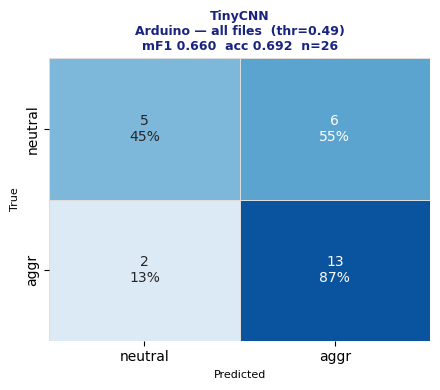

In [17]:
arduino_all   = raw_df[raw_df["source"] == "ARDUINO"].reset_index(drop=True)
train_path_set = set(train_files[train_files["source"] == "ARDUINO"]["path"])
val_path_set   = set(val_files[val_files["source"]   == "ARDUINO"]["path"])
test_path_set  = set(test_files[test_files["source"] == "ARDUINO"]["path"])

def get_split_name(path):
    if path in train_path_set: return "train"
    if path in val_path_set:   return "val"
    if path in test_path_set:  return "test"
    return "?"

print(f"Arduino files: {len(arduino_all)}  "
      f"agg={(arduino_all['label'] == AGGRESSIVE).sum()}  "
      f"neu={(arduino_all['label'] == NEUTRAL).sum()}")

def evaluate_arduino_files(model_name, threshold):
    q      = quantized[model_name]
    interp = q["interp"]
    inp_d  = interp.get_input_details()[0]
    out_d  = interp.get_output_details()[0]

    file_results = []
    total_crops  = {"agg": 0, "neu": 0}

    print(f"\n  {'True':<12} {'Crops':>6}  {'MeanP':>7}  {'MaxP':>6}  {'Pred':<12}  {'Split':<6}  {'OK?':<5}  File")
    print("  " + "-" * 72)

    for _, row in arduino_all.iterrows():
        try:
            audio, _ = librosa.load(row["path"], sr=SAMPLE_RATE)
        except Exception as exc:
            print(f"  skip {row['path']}: {exc}")
            continue

        audio  = audio.astype(np.float32)
        crops  = []
        cursor = 0
        while cursor + TARGET_LEN <= len(audio):
            crops.append(audio[cursor:cursor + TARGET_LEN])
            cursor += CROP_HOP
        if not crops:
            crops = [np.pad(audio, (0, TARGET_LEN - len(audio)))]

        crop_probs = []
        for crop in crops:
            feat  = waveform_to_mel(crop)[np.newaxis]
            x_q   = np.round(feat / q["inp_scale"] + q["inp_zero"]).clip(-128, 127).astype(np.int8)
            interp.set_tensor(inp_d["index"], x_q)
            interp.invoke()
            o_q   = interp.get_tensor(out_d["index"])
            o_f   = (o_q.astype(np.float32) - q["out_zero"]) * q["out_scale"]
            crop_probs.append(float(o_f[0, 1]))

        mean_prob  = float(np.mean(crop_probs))
        max_prob = float(np.max(crop_probs))
        prediction = int(mean_prob >= threshold)
        true_label = LABEL_TO_ID[row["label"]]
        correct    = prediction == true_label
        split      = get_split_name(row["path"])

        total_crops["agg" if row["label"] == AGGRESSIVE else "neu"] += len(crops)
        file_results.append(dict(
            file=os.path.basename(row["path"]), split=split,
            true=row["label"], true_id=true_label,
            pred=ID_TO_LABEL[prediction], pred_id=prediction,
            mean_p=mean_prob, n_crops=len(crops), correct=correct,
        ))
        print(f"  {row['label']:<12} {len(crops):>6}  {mean_prob:>7.3f}  {max_prob:>6.3f}  "
              f"{ID_TO_LABEL[prediction]:<12}  {split:<6}  {'✓' if correct else '✗':<5}  "
              f"{os.path.basename(row['path'])}")

    print("  " + "-" * 72)
    print(f"  Crops: agg={total_crops['agg']}  neu={total_crops['neu']}")
    return file_results


for model_name in sweep_order:
    threshold    = optimal_thresholds.get(model_name, 0.40)
    file_results = evaluate_arduino_files(model_name, threshold)

    true_labels = [r["true_id"]  for r in file_results]
    pred_labels = [r["pred_id"]  for r in file_results]
    n_correct   = sum(r["correct"] for r in file_results)

    mf1 = sk_f1(true_labels, pred_labels, average="macro",    zero_division=0)
    acc = accuracy_score(true_labels, pred_labels)
    r_a = recall_score(true_labels, pred_labels, pos_label=1, zero_division=0)
    r_n = recall_score(true_labels, pred_labels, pos_label=0, zero_division=0)

    print(f"\n{'='*56}")
    print(f"  {model_name}  (thr={threshold:.2f})")
    print(f"{'='*56}")
    print(f"  {n_correct}/{len(file_results)} correct  "
          f"mf1={mf1:.4f}  acc={acc:.4f}  agg_rec={r_a:.4f}  neu_rec={r_n:.4f}")
    print()
    print(classification_report(true_labels, pred_labels, target_names=["neutral", "aggressive"], digits=3))

    for sp in ["train", "val", "test"]:
        sub   = [r for r in file_results if r["split"] == sp]
        if not sub: continue
        yt_s  = [r["true_id"] for r in sub]
        yp_s  = [r["pred_id"] for r in sub]
        mf1_s = sk_f1(yt_s, yp_s, average="macro", zero_division=0)
        ok_s  = sum(r["correct"] for r in sub)
        print(f"  [{sp:>5}]  {ok_s}/{len(sub)} correct  mf1={mf1_s:.3f}")

    # Arduino confusion matrix
    fig, ax = plt.subplots(figsize=(4.5, 4))
    draw_confusion_matrix(ax, true_labels, pred_labels, f"{model_name}\nArduino — all files  (thr={threshold:.2f})")
    plt.tight_layout()
    plt.savefig(f"arduino_cm_{model_name}.png", dpi=130, bbox_inches="tight")
    plt.show()


## 17. Export

In [18]:
EXPORT_MODEL = best_int8
EXPORT_THR   = optimal_thresholds.get(EXPORT_MODEL, 0.40)
q_export     = quantized[EXPORT_MODEL]
r_export     = all_results[EXPORT_MODEL]

def make_model_header(model_bytes, model_name, export_name, n_params, size_kb,
                      mf1, ard_mf1, arena_bytes, threshold,
                      array_name="g_model_data"):
    hex_values = [f"0x{b:02x}" for b in model_bytes]
    hex_lines  = [", ".join(hex_values[i:i+12]) for i in range(0, len(hex_values), 12)]
    hex_block  = ",\n  ".join(hex_lines)
    return (
        f"// Auto-generated — aggression_classifier_final.ipynb\n"
        f"// Model       : {export_name} ({model_name})\n"
        f"// Params      : {n_params:,}  |  Size: {size_kb:.1f} KB\n"
        f"// test mF1    : {mf1:.4f}\n"
        f"// arduino mF1 : {ard_mf1:.4f}\n"
        f"//\n"
        f"// Feature pipeline (matches AggressionClassifier.ino)\n"
        f"//   SAMPLE_RATE={SAMPLE_RATE}  N_FFT={N_FFT}  HOP_LENGTH={HOP_LENGTH}\n"
        f"//   N_MELS={N_MELS}  fmin={MEL_FMIN}  fmax={MEL_FMAX}  htk=True\n"
        f"//\n"
        f"// Deployment\n"
        f"//   TFLITE_ARENA_SIZE  = {arena_bytes}  ({arena_bytes // 1024} KB)\n"
        f"//   DECISION_THRESHOLD = {threshold:.2f}f\n"
        f"//   VOTE_WINDOW        = 2\n"
        f"\n#ifndef MODEL_DATA_H\n#define MODEL_DATA_H\n\n"
        f"const unsigned char {array_name}[] = {{\n  {hex_block}\n}};\n\n"
        f"const unsigned int {array_name}_len = {len(model_bytes)};\n\n"
        f"#endif  // MODEL_DATA_H\n"
    )

header_text = make_model_header(
    model_bytes=q_export["model_bytes"],
    model_name=r_export["model"].name,
    export_name=EXPORT_MODEL,
    n_params=r_export["params"],
    size_kb=q_export["size_kb"],
    mf1=q_export["mf1"],
    ard_mf1=q_export["ard_mf1"],
    arena_bytes=q_export["arena"],
    threshold=EXPORT_THR,
)

with open(MODEL_HEADER_PATH, "w")  as f: f.write(header_text)
with open(TFLITE_PATH,       "wb") as f: f.write(q_export["model_bytes"])

print(f"Wrote {MODEL_HEADER_PATH}  ({len(q_export['model_bytes']):,} bytes)")
print(f"Wrote {TFLITE_PATH}")

print(f"\n  Model              : {EXPORT_MODEL}")
print(f"  Params             : {r_export['params']:,}")
print(f"  int8 size          : {q_export['size_kb']:.1f} KB")
print(f"  TFLITE_ARENA_SIZE  = {q_export['arena']}  ({q_export['arena'] // 1024} KB)")
print(f"  DECISION_THRESHOLD = {EXPORT_THR:.2f}f")
print(f"  test mF1           : {q_export['mf1']:.4f}")
print(f"  arduino mF1        : {q_export['ard_mf1']:.4f}")

print("\nAll models saved:")
for name in sorted(quantized, key=lambda k: -quantized[k]["ard_mf1"]):
    q  = quantized[name]
    fn = f"model_{name.lower()}.tflite"
    with open(fn, "wb") as f: f.write(q["model_bytes"])
    print(f"  {fn:<38} {q['size_kb']:.1f} KB  ard_mf1={q['ard_mf1']:.4f}")


Wrote model_data.h  (28,248 bytes)
Wrote model_integer_quant.tflite

  Model              : TinyResidualNet
  Params             : 8,906
  int8 size          : 27.6 KB
  TFLITE_ARENA_SIZE  = 28672  (28 KB)
  DECISION_THRESHOLD = 0.49f
  test mF1           : 0.7050
  arduino mF1        : 0.4722

All models saved:
  model_tinycnn.tflite                   24.4 KB  ard_mf1=0.6244
  model_tinyresidualnet.tflite           27.6 KB  ard_mf1=0.4722
